https://github.com/jgehrcke/covid-19-germany-gae/blame/master/cases-rki-by-ags.csv

data saved in same folder as other survstat data

## dataprocessing

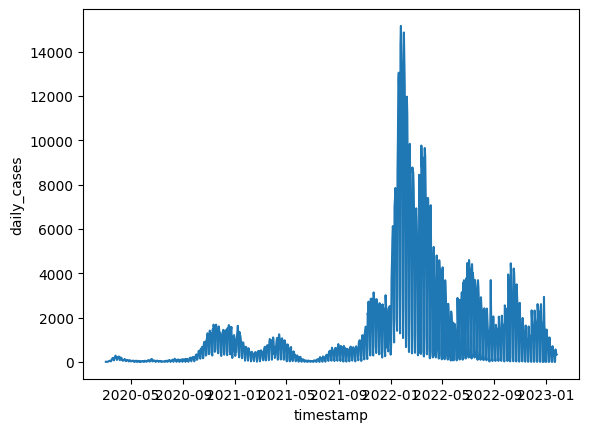

In [1]:
from src.utils import get_data_env
import os 
import pandas as pd
from itertools import product

raw_data = pd.read_csv(os.path.join(get_data_env(),'raw/cases-rki-by-ags.csv'))
raw_data['timestamp'] =  pd.to_datetime(raw_data['time_iso8601']).dt.date
raw_data.drop(columns = ['time_iso8601'], inplace = True)

raw_data_long           =  raw_data.melt(id_vars = 'timestamp', var_name='nuts3', value_name='cases')
raw_data_long['nuts3']  = raw_data_long['nuts3'].str.zfill(5)

# one error in nuts3: 16056 has become part of 16063
raw_data_long.loc[raw_data_long['nuts3'] == '16056', 'nuts3'] = '16063'

# Filter out unwanted nuts3 codes FIRST
filter_nuts = ['11001','11002','11003','11004','11005','11006','11007','11008','11009','11010','11011','11012','sum_cases']
raw_data_long = raw_data_long[~raw_data_long['nuts3'].isin(filter_nuts)]

# Group by timestamp and nuts3
raw_data_long = raw_data_long.groupby(['timestamp','nuts3'])['cases'].sum().reset_index(drop = False)

# NOW create complete index with only the remaining nuts3 codes
all_timestamps = raw_data_long['timestamp'].unique()
all_nuts3 = raw_data_long['nuts3'].unique()

complete_index = pd.DataFrame(
    list(product(all_timestamps, all_nuts3)),
    columns=['timestamp', 'nuts3']
)

# Merge to find missing combinations and fill with 0
raw_data_long = complete_index.merge(
    raw_data_long, 
    on=['timestamp', 'nuts3'], 
    how='left'
)
raw_data_long['cases'] = raw_data_long['cases'].fillna(0)

# Continue with processing
df = raw_data_long.sort_values(['nuts3', 'timestamp'])

df['daily_cases'] = df.groupby('nuts3')['cases'].diff()
df.loc[df['daily_cases'] < 0, 'daily_cases'] = 0
import seaborn as sns
df['timestamp'] = pd.to_datetime(df['timestamp'])
sns.lineplot(df[df['nuts3'] == '11000'], x = 'timestamp', y = 'daily_cases')

preprocessed_data = df[['timestamp','nuts3','daily_cases']].rename(columns = {'daily_cases':'cases','nuts3':'kz_kreis'})
iso = df['timestamp'].dt.isocalendar()

preprocessed_data['year'] = iso.year
preprocessed_data['week'] = iso.week
preprocessed_data['day'] = iso.day

preprocessed_data.loc[preprocessed_data['cases'].isna(), 'cases'] = 0
preprocessed_data.reset_index(drop = True, inplace=True)
preprocessed_data = preprocessed_data[['week','kz_kreis','cases','year','timestamp','day']]
preprocessed_data.to_csv(os.path.join(get_data_env(),'processed/germany/epidemiology/casedata/survstat/covid_daily.csv'), index=False)

## dataloading

In [2]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator, ShallowDataLoaderManager, GraphDataLoaderManager, DeepDataLoaderManager
from src.models import ConstantModel, PersistenceModel, ClimateologyModel, NodeLSTMModel, NodeGRUModel, GATv2Model, SpatialGNNModel

# get data
disease_name    = 'covid_daily'
nuts_level      = 'nuts3'
min_date        = '2020-03-02'
max_date        = '2023-01-01'
split_trainval  = '2022-06-01'
split_valtest   = '2022-09-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 7
sequence_length = 1
lag_num         = 1

config = EpiConfig(
    disease             = disease_name,
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    temporal_frequency   = "d",
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = split_berlin,
    include_population  = False,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'incidence',
    lag_column          = 'incidence',  
    verbose             = 0  ,
    weekly_time_index   = False,
    daily_time_index    = True,
    )    

data_orchestrator = (DataOrchestrator(config)
                        .load_raw()
                        .harmonize_raw()
                        .process_data()
                        .build_features()
                        .normalize()
                        .finalize()
                        )

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/pyogrio/raw.py:198: RuntimeWarning: /local/job_23501062/wissdaten/ZKI-PH4/deschrijvers_wissdaten/data/processed/germany/geospatial/shapefiles/shape_nuts3.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


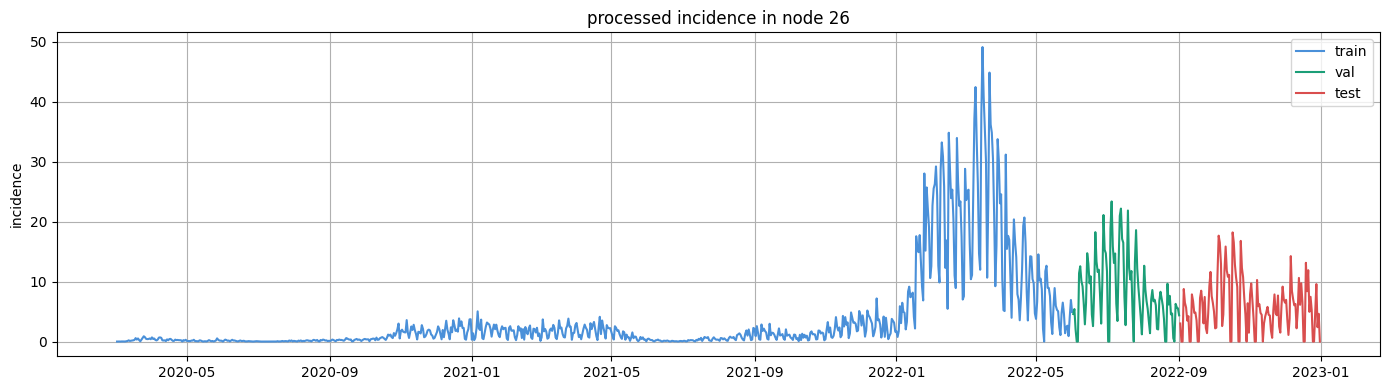

In [3]:
import pandas as pd
data_orchestrator.preview(26).show()

In [4]:
from src.dataloading import ShallowDataLoaderManager, GraphDataLoaderManager
from src.models import PersistenceModel, ClimateologyModel

sl = ShallowDataLoaderManager(data_orchestrator).construct_dataloaders()
dl = DeepDataLoaderManager(data_orchestrator).construct_dataloaders()

gl1 = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('identity_graph').construct_dataloaders()
gl2 = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('geographical_neighbors1').construct_dataloaders()
gl3 = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('static_commuter24_1').construct_dataloaders()

ps = PersistenceModel(sl)
cm = ClimateologyModel(sl)

ps.forecast('test')
raw_f1 = ps.show_forecasts([26], 'test')

cm.forecast('test')
raw_f2 = cm.show_forecasts([26], 'test')

f1 = (raw_f1
      .labels.change_suptitle('Persistence model','bold',12)
      .labels.change_title('Predictions node 26: Hannover')
      .labels.change_xlab('time')
      .labels.change_ylab('incidence')
      .legend.set_labels(['true incidence','persistence model'])
      .change_figsize(10,5).legend.move('upper left'))

f2 = (raw_f2
      .labels.change_suptitle('Climateology model','bold',12)
      .labels.change_title('Predictions node 26: Hannover')
      .labels.change_xlab('time')
      .labels.change_ylab('incidence')
      .legend.set_labels(['true incidence','climateology model'])
      .change_figsize(10,5).legend.move('upper left'))

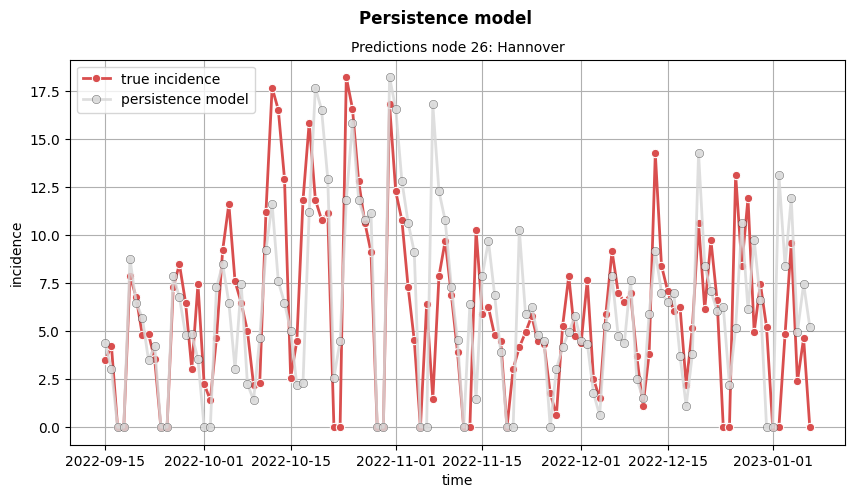

In [5]:
f1.show()

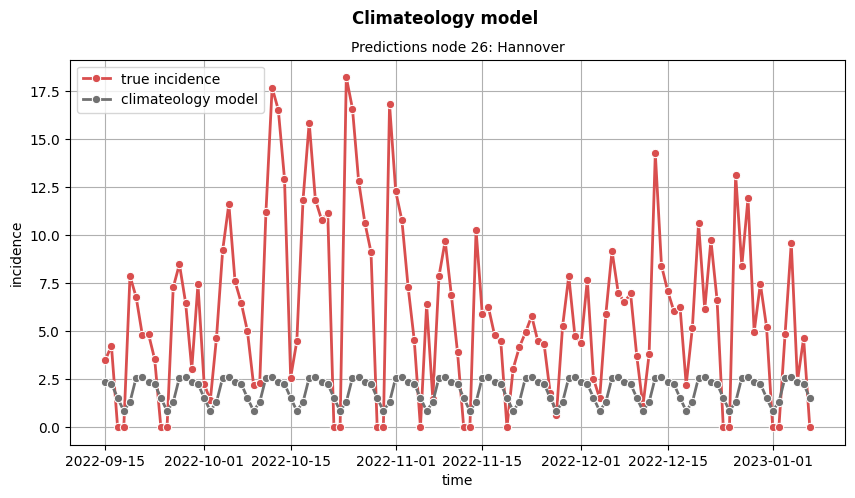

In [6]:
f2.show()

In [ ]:
from src.models import NodeLSTMModel

lr = 0.00001

n_epochs= 250
min_delta = 0
loss = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 10,
    }

lstm = NodeLSTMModel(dl, verbose = 2)
lstm.set_model_hparams()
lstm.set_global_hparams(**global_hparams)
lstm.train()
lstm.forecast('test')
lstm.show_forecasts(26).show()


==                   nodelstm                   ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: DeepData(x=(400, 3, 1), y=(400, 1))
Epoch 001 train loss: 0.6913, val loss: 0.4988 ✓ (new best)
Epoch 002 train loss: 0.2709, val loss: 0.4011 ✓ (new best)



==              gcn_identity_graph              ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 5, 1), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))
Epoch 001 train loss: 0.8861, val loss: 1.3207 ✓ (new best)
Epoch 002 train loss: 0.8058, val loss: 1.2049 ✓ (new best)
Epoch 003 train loss: 0.7111, val loss: 1.0671 ✓ (new best)
Epoch 004 train loss: 0.6052, val loss: 0.9141 ✓ (new best)
Epoch 005 train loss: 0.4995, val loss: 0.7572 ✓ (new best)
Epoch 006 train loss: 0.4034, val loss: 0.6088 ✓ (new best)
Epoch 007 train loss: 0.3289, val loss: 0.4833 ✓ (new best)
Epoch 008 train loss: 0.2789, val loss: 0.3903 ✓ (new best)
Epoch 009 train loss: 0.2500, val loss: 0.3336 ✓ (new best)
Epoch 010 train loss: 0.2341, val loss: 0.3065 ✓ (new best)
Epoch 011 train loss: 0.2251, val loss: 0.2966 ✓ (new best)
Epoch 012 train loss: 0.2194, val loss: 0.2949 ✓ (new best)
Epoch 013 train loss: 0.2157, val loss: 0.2958 (patience: 1/10)
Epoch 014 train loss: 0.

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:242: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 10 epochs
Restored model from best validation loss: 0.2949
trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 108/108 [00:00<00:00, 625.13it/s]


Test loss: 0.3064
forecasted ✓

==              gcn_geo_neighbors               ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 5, 1), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))
Epoch 001 train loss: 0.9344, val loss: 1.7305 ✓ (new best)
Epoch 002 train loss: 0.8843, val loss: 1.6748 ✓ (new best)
Epoch 003 train loss: 0.8237, val loss: 1.6073 ✓ (new best)
Epoch 004 train loss: 0.7512, val loss: 1.5240 ✓ (new best)
Epoch 005 train loss: 0.6677, val loss: 1.4224 ✓ (new best)
Epoch 006 train loss: 0.5775, val loss: 1.3095 ✓ (new best)
Epoch 007 train loss: 0.4938, val loss: 1.1901 ✓ (new best)
Epoch 008 train loss: 0.4193, val loss: 1.0607 ✓ (new best)
Epoch 009 train loss: 0.3581, val loss: 0.9316 ✓ (new best)
Epoch 010 train loss: 0.3099, val loss: 0.8181 ✓ (new best)
Epoch 011 train loss: 0.2773, val loss: 0.7260 ✓ (new best)
Epoch 012 train loss: 0.2565, val loss: 0.6565 ✓ (new best)
Epoch 013 train loss: 0.2423, val loss: 0.6083 ✓ (new b

...

Test loss: 0.3230
forecasted ✓

==                 gcn_commuter                 ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 5, 1), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))
Epoch 001 train loss: 0.9408, val loss: 1.6864 ✓ (new best)
Epoch 002 train loss: 0.8827, val loss: 1.5913 ✓ (new best)
Epoch 003 train loss: 0.8108, val loss: 1.4758 ✓ (new best)
Epoch 004 train loss: 0.7248, val loss: 1.3411 ✓ (new best)
Epoch 005 train loss: 0.6284, val loss: 1.1940 ✓ (new best)
Epoch 006 train loss: 0.5272, val loss: 1.0374 ✓ (new best)
Epoch 007 train loss: 0.4292, val loss: 0.8809 ✓ (new best)
Epoch 008 train loss: 0.3405, val loss: 0.7410 ✓ (new best)
Epoch 009 train loss: 0.2729, val loss: 0.6320 ✓ (new best)
Epoch 010 train loss: 0.2316, val loss: 0.5567 ✓ (new best)
Epoch 011 train loss: 0.2120, val loss: 0.5106 ✓ (new best)
Epoch 012 train loss: 0.2043, val loss: 0.4836 ✓ (new best)
Epoch 013 train loss: 0.2006, val loss: 0.4654 ✓ (new bes

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:242: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 10 epochs
Restored model from best validation loss: 0.3858
trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 108/108 [00:00<00:00, 630.15it/s]


Test loss: 0.3018
forecasted ✓


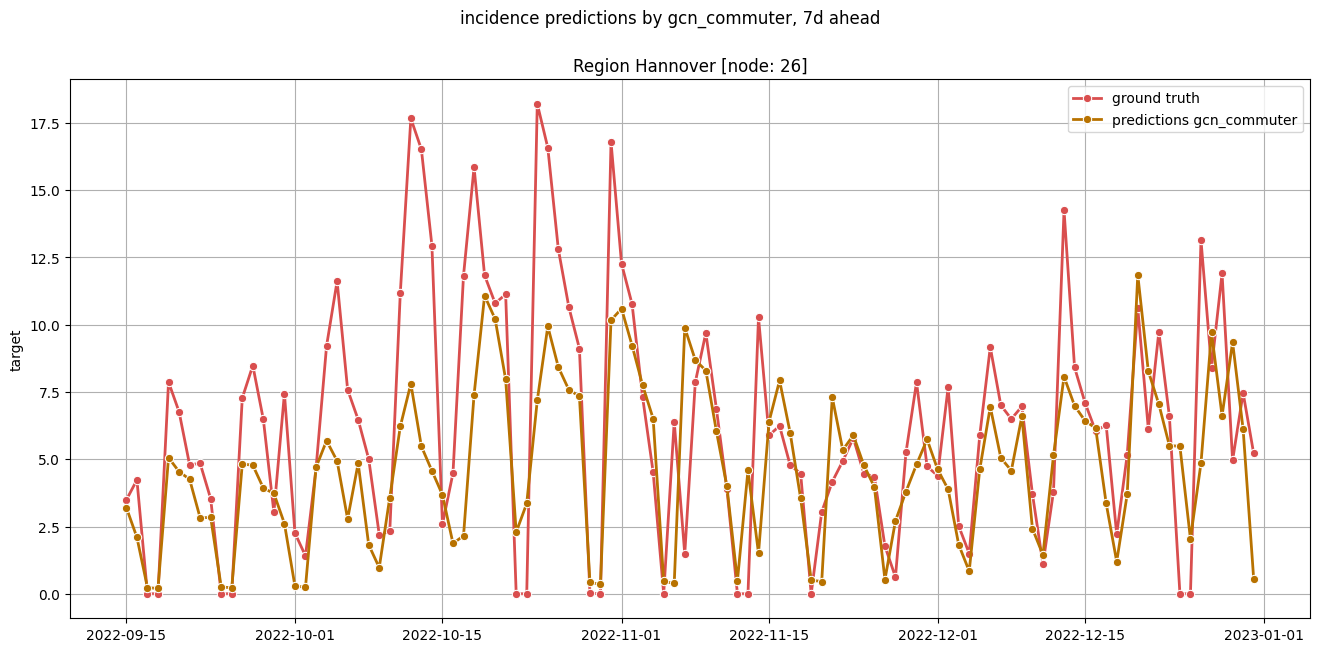

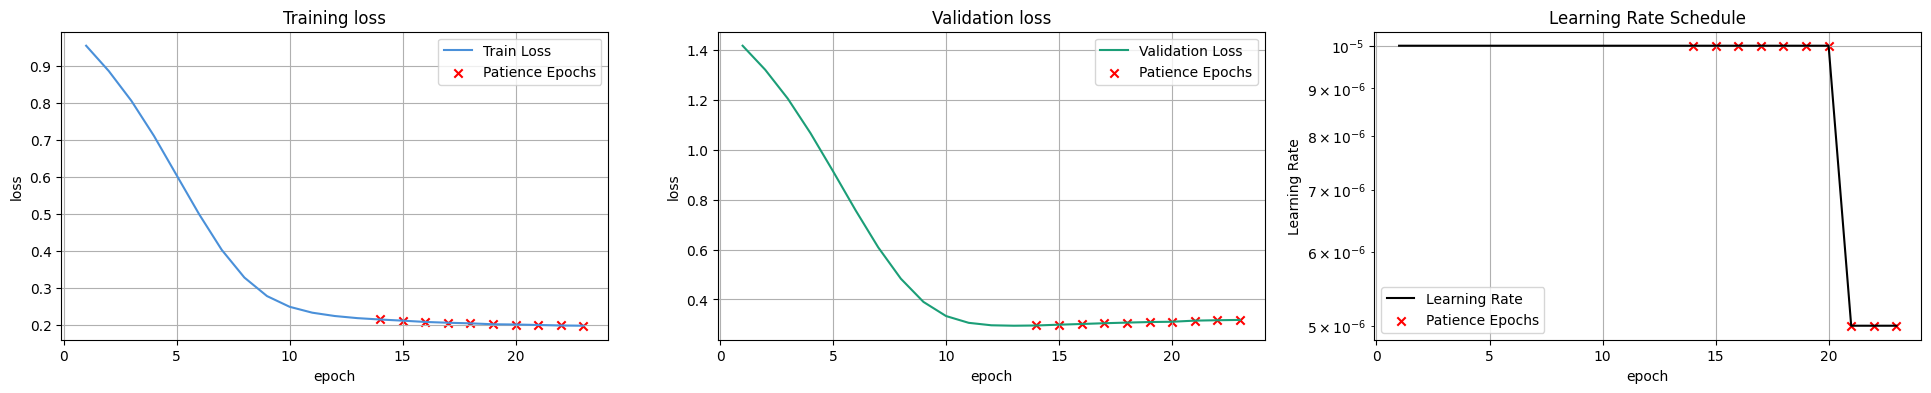

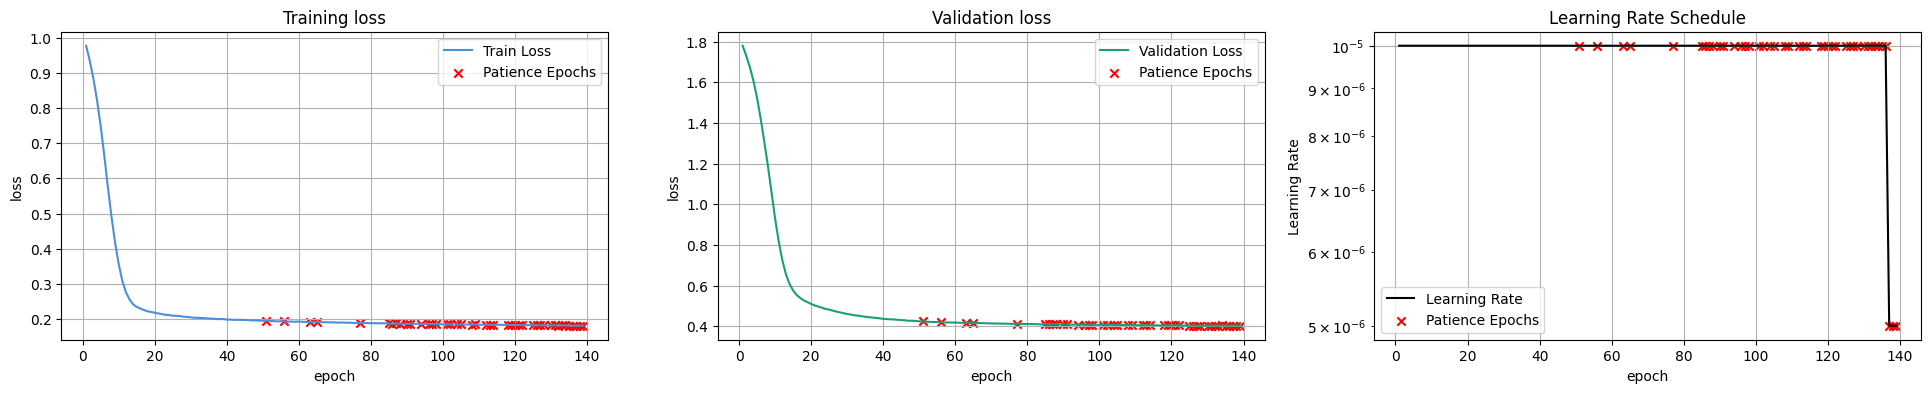

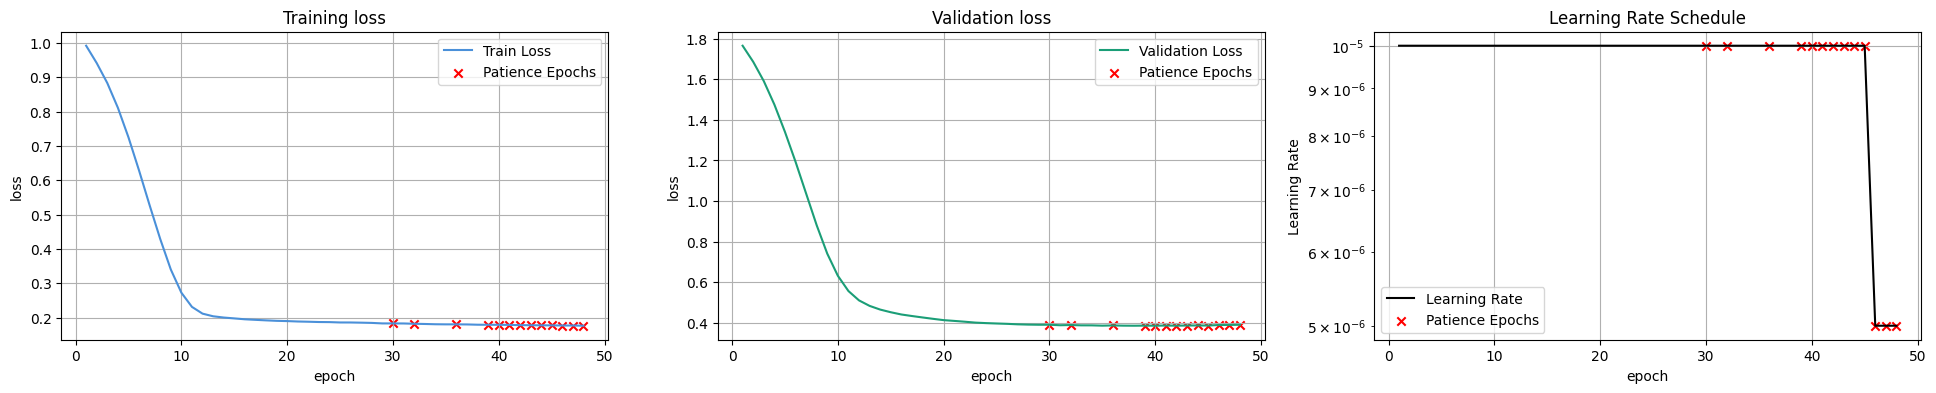

In [ ]:
from src.models import SpatialGNNModel

lr = 0.00001

min_delta = 0
loss = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 10,
    }

gcn1 = SpatialGNNModel(gl1, name='gcn_identity_graph', verbose = 2)
gcn1.set_model_hparams()
gcn1.set_global_hparams(**global_hparams)
gcn1.train()
gcn1.forecast('test')
gcn1.show_forecasts(26).show()

gcn2 = SpatialGNNModel(gl2, name='gcn_geo_neighbors', verbose = 2)
gcn2.set_model_hparams()
gcn2.set_global_hparams(**global_hparams)
gcn2.train()
gcn2.forecast('test')
gcn2.show_forecasts(26).show()

gcn3 = SpatialGNNModel(gl1, name='gcn_commuter', verbose = 2)
gcn3.set_model_hparams()
gcn3.set_global_hparams(**global_hparams)
gcn3.train()
gcn3.forecast('test')
gcn3.show_forecasts(26).show()

In [ ]:
from src.models import GATv2Model

lr = 0.00001
min_delta = 0
loss = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 10,
    }

gat1 = GATv2Model(gl1, name='gatv2_identity_graph', verbose = 2)
gat1.set_model_hparams()
gat1.set_global_hparams(**global_hparams)
gat1.train()
gat1.forecast('test')
gat1.show_forecasts(26).show()

gat2 = GATv2Model(gl2, name='gatv2_geo_neighbors', verbose = 2)
gat2.set_model_hparams()
gat2.set_global_hparams(**global_hparams)
gat2.train()
gat2.forecast('test')
gat2.show_forecasts(26).show()

gat3 = GATv2Model(gl3, name='gatv2_commuter', verbose = 2)
gat3.set_model_hparams()
gat3.set_global_hparams(**global_hparams)
gat3.train()
gat3.forecast('test')
gat3.show_forecasts(26).show()


==             gatv2_identity_graph             ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 5, 1), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))
Epoch 001 train loss: 0.3139, val loss: 0.9572 (patience: 1/10)
Epoch 002 train loss: 0.2814, val loss: 0.8423 ✓ (new best)
Epoch 003 train loss: 0.2563, val loss: 0.7034 ✓ (new best)
Epoch 004 train loss: 0.2365, val loss: 0.5904 ✓ (new best)
Epoch 005 train loss: 0.2208, val loss: 0.5188 ✓ (new best)
Epoch 006 train loss: 0.2097, val loss: 0.4742 ✓ (new best)
Epoch 007 train loss: 0.2011, val loss: 0.4480 ✓ (new best)
Epoch 008 train loss: 0.1943, val loss: 0.4284 ✓ (new best)
Epoch 009 train loss: 0.1892, val loss: 0.4141 ✓ (new best)
Epoch 010 train loss: 0.1847, val loss: 0.4008 ✓ (new best)


Epoch 011 train loss: 0.1820, val loss: 0.3893 ✓ (new best)
Epoch 012 train loss: 0.1791, val loss: 0.3807 ✓ (new best)
Epoch 013 train loss: 0.1773, val loss: 0.3725 ✓ (new best)
Epoch 014 train loss: 0.1758, val loss: 0.3646 ✓ (new best)
Epoch 015 train loss: 0.1750, val loss: 0.3591 ✓ (new best)
Epoch 016 train loss: 0.1731, val loss: 0.3539 ✓ (new best)
Epoch 017 train loss: 0.1721, val loss: 0.3478 ✓ (new best)
Epoch 018 train loss: 0.1711, val loss: 0.3442 ✓ (new best)
Epoch 019 train loss: 0.1698, val loss: 0.3401 ✓ (new best)
Epoch 020 train loss: 0.1693, val loss: 0.3374 ✓ (new best)


KeyboardInterrupt: 

In [ ]:
predictioncollection = gat3.predictions.get_preds('test')
timesteps_ahead          = int(gat3.dataloadermanager.dataorchestrator.config.horizon_leadtime + 0)
evaluation_df = predictioncollection.get_original(0)

In [ ]:
evaluation_df

evaluation_df['pred_moving'] = evaluation_df.groupby('node').rolling(7)['pred'].mean().reset_index(drop=True)
evaluation_df['target_moving'] = evaluation_df.groupby('node').rolling(7)['target'].mean().reset_index(drop=True)



NameError: name 'sns' is not defined

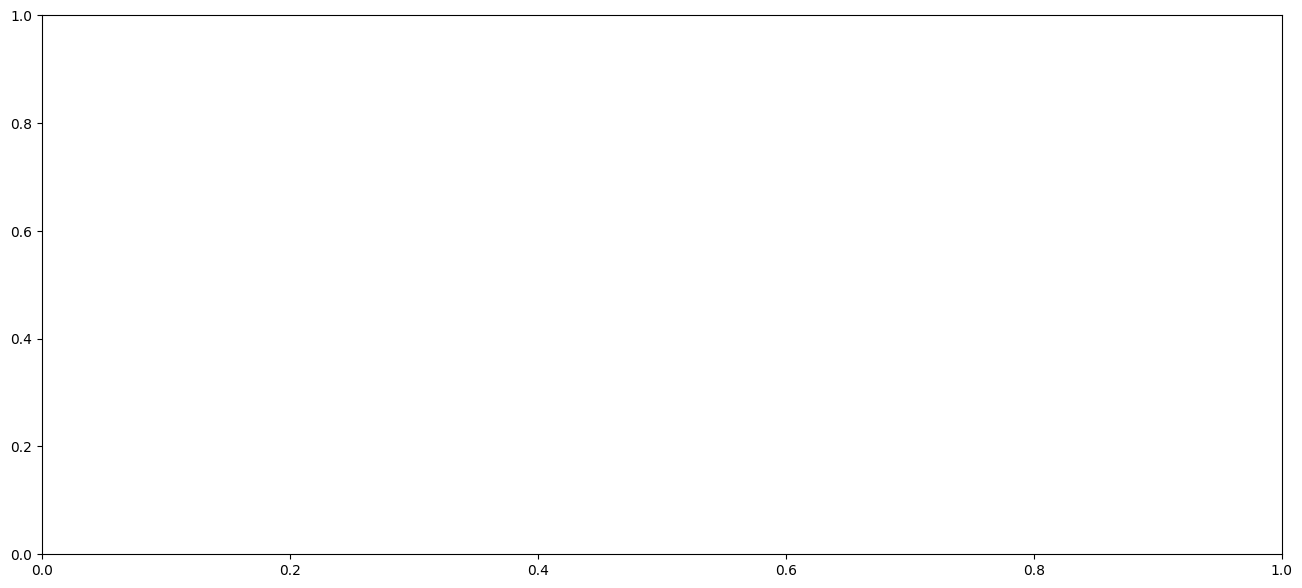

In [ ]:
import matplotlib.pyplot as plt 
import seaborn as sns
from src.utils.colors import color_is_light, testcolor

node_idx = 353

moving_average = True



if isinstance(node_idx, int):
    node_idx = [node_idx]

n_plots     = len(node_idx)
fig, axes   = plt.subplots(n_plots ,1, figsize = (16, 2 + (5 * n_plots)))

if n_plots > 1:
    axes        = axes.flatten()           
else:
    axes = [axes]

for counter, id in enumerate(node_idx):
    ax = axes[counter]
    nutscode = gat3.tokenization_map['idx_id'][id]
    nodename = gat3.nutsnames[gat3.nutsnames[f'{gat3.nutslevel}_key'] == nutscode][f'{gat3.nutslevel}_name'].iloc[0]

    evaluation_df_node  = evaluation_df[evaluation_df['node'] == id]
    if moving_average:
        sns.lineplot(data   = evaluation_df_node, x = 'timestamp', y = 'target_moving',    color = testcolor,          marker = 'o',   label = 'ground truth moving average', ax = ax, linewidth = 2)

    else:
        sns.lineplot(data   = evaluation_df_node, x = 'timestamp', y = 'target',    color = testcolor,          marker = 'o',   label = 'ground truth', ax = ax, linewidth = 2)

    # if the luminence of the color is too high for a white background we give a black outline of line and marker
    if color_is_light(gat3.model_color):                  
        if moving_average:
            sns.lineplot(data   = evaluation_df_node, x = 'timestamp', y = 'pred_moving',color = gat3.model_color,   marker = 'o',   label = f'predictions moving average {gat3.name}',    ax = ax, linewidth = 2, markeredgecolor = 'black', markeredgewidth=0.2)        
        else:
            sns.lineplot(data   = evaluation_df_node, x = 'timestamp', y = 'pred',      color = gat3.model_color,   marker = 'o',   label = f'predictions {gat3.name}',    ax = ax, linewidth = 2, markeredgecolor = 'black', markeredgewidth=0.2)
        
    else:
        if moving_average:
            sns.lineplot(data   = evaluation_df_node, x = 'timestamp', y = 'pred_moving',color = gat3.model_color,   marker = 'o',   label = f'predictions moving average {gat3.name}',    ax = ax, linewidth = 2)        
        else:
            sns.lineplot(data   = evaluation_df_node, x = 'timestamp', y = 'pred',      color = gat3.model_color,   marker = 'o',   label = f'predictions {gat3.name}',    ax = ax, linewidth = 2)
    ax.set_title(f'{nodename} [node: {id}]')
    ax.set_xlabel("")            
    ax.grid()   

In [ ]:
evaluation_df_node[['pred_moving','target_moving']].corr()

,pred_moving,target_moving
pred_moving,1.00000,0.67988
target_moving,0.67988,1.00000


In [ ]:
from src.evaluation.metrics import RegressionMetrics

normal_metrics = RegressionMetrics(target_col = 'target', pred_col = 'pred')
print(f'ccc predictions {normal_metrics.ccc(evaluation_df_node)}')
rolling_average_metrics = RegressionMetrics(target_col = 'target_moving', pred_col = 'pred_moving')
print(f'ccc moving average predictions {rolling_average_metrics.ccc(evaluation_df_node)}')

ccc predictions 0.6722529530525208
ccc moving average predictions 0.5389279457305705


computing metrics: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:01<00:00,  3.05it/s]
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. af

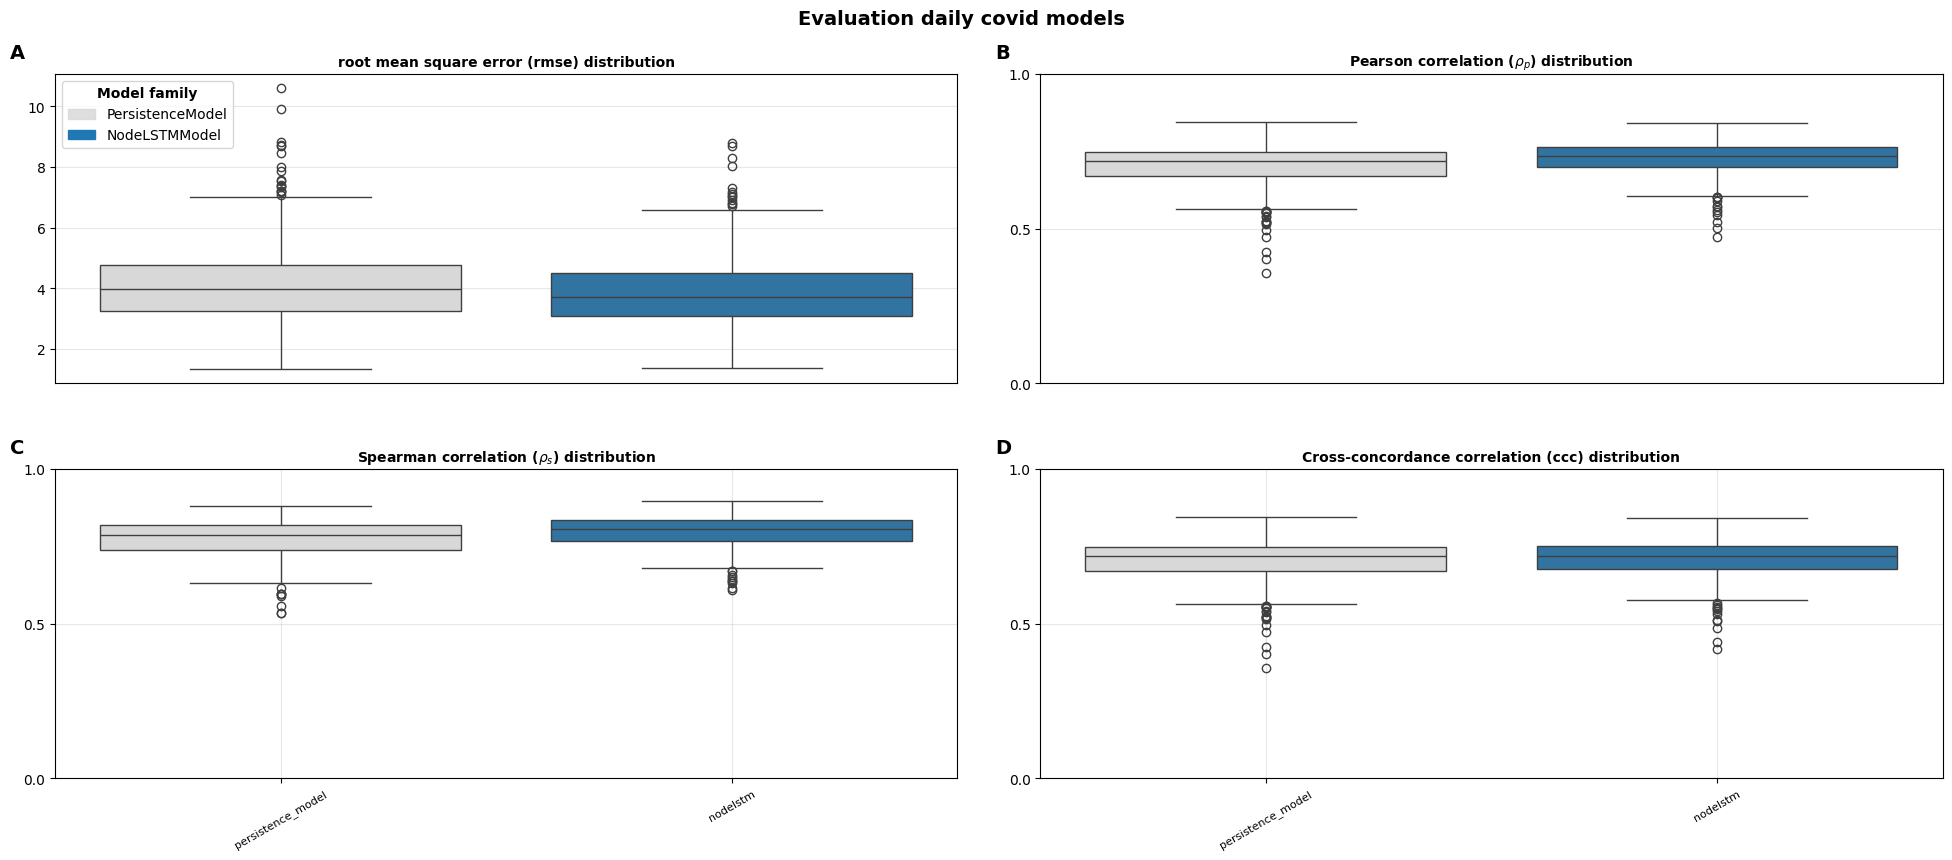

In [ ]:
from src.evaluation import Evaluator

e = Evaluator([ps, lstm, gcn1,gcn2,gcn3, gat1, gat2, gat3]).add_evaluation()
raw_figure = e.plotter.plot_metric_compilation(plot_types = ['box','box','box','box'], metrics = ['rmse','pearson_corr','spearman_corr','ccc'])

f_evaluation = (raw_figure
    .labels.change_suptitle(suptitle='Evaluation daily covid models', fontsize = 14, fontweight = 'bold')
    .labels.set_suptitle_y(y=1.05)
    .labels.change_title('root mean square error (rmse) distribution', fontweight = 'bold',         ax = 0)      
    .labels.change_title('Pearson correlation ($\\rho_{p}$) distribution', fontweight = 'bold',     ax = 1)
    .labels.change_title('Spearman correlation ($\\rho_s$) distribution',  fontweight = 'bold',     ax = 2)
    .labels.change_title('Cross-concordance correlation (ccc) distribution', fontweight = 'bold',   ax = 3)    
    .labels.change_ylab('')
    .labels.change_xlab("")
    .ticks.change_xticks([], ax = 0)
    .ticks.change_xticks([], ax = 1)    
    .ticks.change_yticks(ticks = [0,0.5,1], ax = 1)
    .ticks.change_yticks(ticks = [0,0.5,1], ax = 2)
    .ticks.change_yticks(ticks = [0,0.5,1], ax = 3)    
    .ticks.rotate_xticks(30)
    .layout.set_ylim([0,1],ax = 1)
    .layout.set_ylim([0,1],ax = 2)
    .layout.set_ylim([0,1],ax = 3)        
    .labels.change_legend_title('Model family',fontweight = 'bold',ax=0)
    .labels.set_tag('A', y = 1.1, ax = 0)   
    .labels.set_tag('B', y = 1.1, ax = 1) 
    .labels.set_tag('C', y = 1.1, ax = 2) 
    .labels.set_tag('D', y = 1.1, ax = 3)      
    .legend.move('upper left', ax = 0)      
    .change_figsize(20,8)         
    )
f_evaluation.show()

In [ ]:
metrics = e.metric_compilations.get_compilation('horizon_0','test')

In [ ]:
ccc = metrics['ccc']

In [ ]:
ccc['gatv2_commuter'].sort_values()

32     0.391470
327    0.395394
266    0.399065
224    0.403206
223    0.414245
         ...   
334    0.764246
249    0.773314
329    0.791733
135    0.793628
220    0.796591
Name: gatv2_commuter, Length: 400, dtype: float32

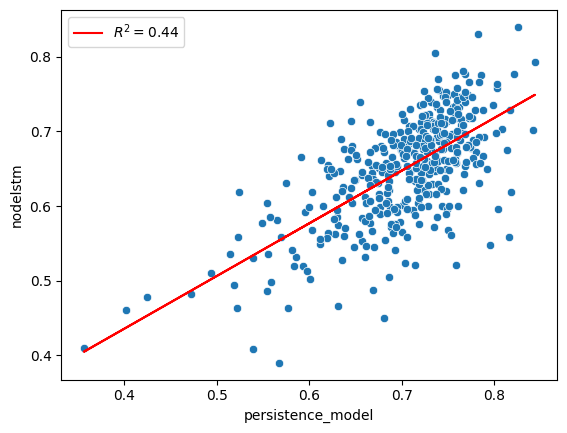

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress

model2 = 'nodelstm'
model1 = 'persistence_model'

# scatter plot
sns.scatterplot(data=ccc, x=model1, y=model2)

# fit linear regression
x = ccc[model1]
y = ccc[model2]
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# overlay regression line
plt.plot(x, intercept + slope*x, color='red', label=f'$R^2 = {r_value**2:.2f}$')

plt.legend()
plt.show()
